# Heart Disease Classification



## Project Overview

The objective of this project is to analyze a cardiovascular disease dataset, identify relationships between medical and lifestyle factors, and develop machine learning models capable of predicting heart disease.

In [143]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Set default Seaborn theme and color palette
sns.set_theme(
    style="whitegrid",  # Options: "darkgrid", "whitegrid", "dark", "white", "ticks"
    rc={
        "axes.labelsize": 12,  # Font size for axis labels
        "axes.titlesize": 14,  # Font size for titles
        "xtick.labelsize": 10,  # Font size for x-axis tick labels
        "ytick.labelsize": 10,  # Font size for y-axis tick labels
        "axes.edgecolor": "black",  # Border color of plots
        "axes.spines.top": False,  # Hide top border
        "axes.spines.right": False,  # Hide right border
        "grid.color": "#DDDDDD",  # Light grid color
    }
)

custom_palette = {"bar": "#7E30E1"}  # Define bar color
sns.set_palette([custom_palette["bar"]])  # Apply the color globally


## Dataset
The dataset contains medical measurements and lifestyle information for thousands of patients. Each observation includes features that may contribute to cardiovascular disease, making it suitable for both exploratory analysis and classification.

In [144]:
df = pd.read_csv("cardio.csv")
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc
count,70000.000000,69997.000000,69996.000000,69997.000000,69990.000000,69984.000000,69999.000000,70000.000000
mean,52.840671,1.349572,164.358620,74.204709,127.172596,93.955033,1.366877,1.226457
std,6.766774,0.476838,8.209967,14.396144,29.454769,109.015262,0.680254,0.572270
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,2000.000000,2080.000000,3.000000,3.000000


## Data Cleaning
Before any analysis or model training, the dataset is cleaned to improve data quality. This includes handling missing values, removing unnecessary information, and preparing the data for machine learning.

In [145]:
df.isna().sum()


age             0
gender          3
height          4
weight          3
ap_hi          10
ap_lo          16
cholesterol     1
gluc            0
smoke          41
alco           43
active         62
cardio          0
dtype: int64

In [146]:
df.dropna(inplace=True)

## Data Mapping
Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical representations while preserving the meaning of each category.

In [147]:
df["smoke"] = df["smoke"].map({"yes": 1, "no": 0,'NaN':-1})
df['alco'] = df['alco'].map({'yes': 1, 'no': 0})
df['active'] = df['active'].map({'yes': 1, 'no': 0})
df['cardio'] = df['cardio'].map({'yes': 1, 'no': 0})

## Exploratory Data Analysis
Exploratory Data Analysis is performed to better understand the dataset. Visualizations and summary statistics help identify patterns, distributions, and potential relationships between variables.

<Axes: xlabel='smoke', ylabel='count'>

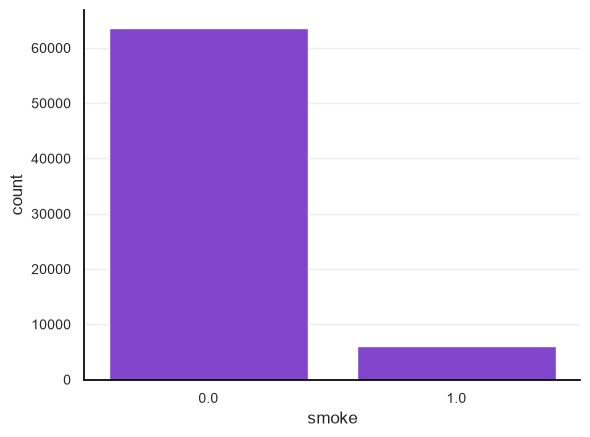

In [148]:
sns.countplot(data=df,x='smoke')

<Axes: xlabel='alco', ylabel='count'>

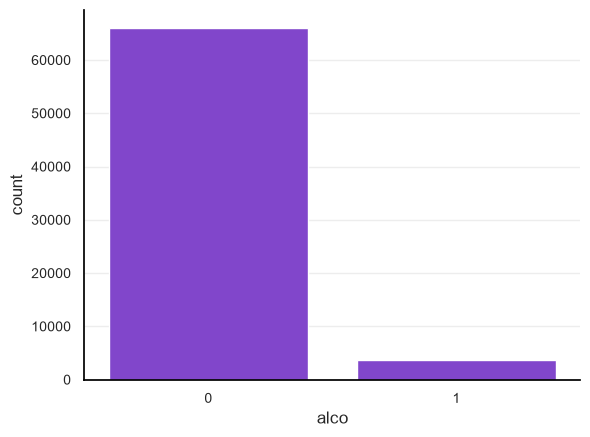

In [149]:
sns.countplot(data=df,x='alco')

In [150]:
df['smoke'].mode()

0    0.0
Name: smoke, dtype: float64

In [151]:
df["alco"].mode()

0    0
Name: alco, dtype: int64

Text(0.5, 1.0, 'Histogram of height in cardio dataset')

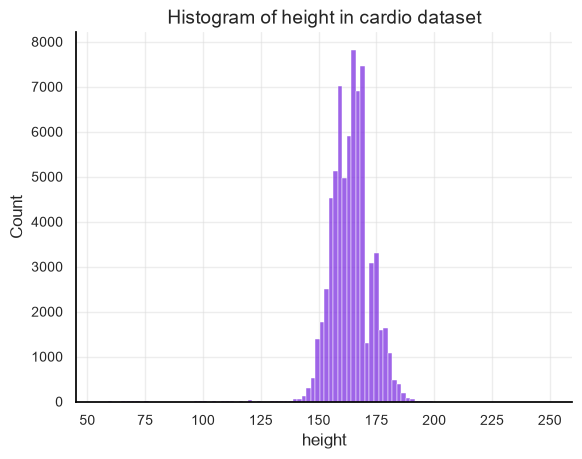

In [152]:
sns.histplot(data=df,x='height',bins=100)
plt.title("Histogram of height in cardio dataset")

Text(0.5, 1.0, 'Histogram of weight in cardio dataset')

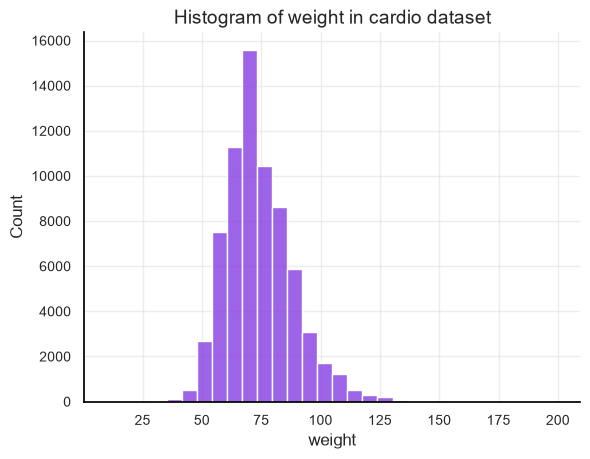

In [153]:
sns.histplot(data=df,x='weight',bins=30)
plt.title("Histogram of weight in cardio dataset")

Text(0.5, 1.0, 'Boxplot of age in cardio dataset')

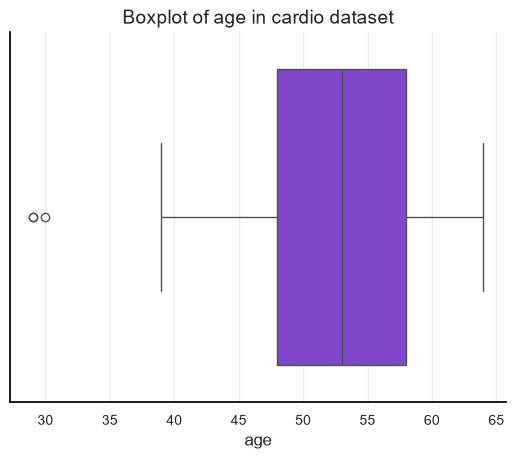

In [154]:
sns.boxplot(data=df,x='age')
plt.title("Boxplot of age in cardio dataset")

In [155]:
df["height"].mean()

np.float64(164.34908361970218)

In [156]:
df["weight"].mean()

np.float64(74.20469644902634)

In [157]:
df["age"].mean()

np.float64(52.84390034364261)

## Feature Engineering (Measures of Central Tendency Within Cardiovascular Disease Groups)
This section examines the statistical properties of the dataset. Measures such as the mean, median, and standard deviation provide insight into the characteristics of each feature and how they differ between patient groups.

In [158]:
dfYesCardio = df[df['cardio']==1]
dfNoCardio = df[df['cardio']==0]

In [159]:
cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
for group, df_group in df.groupby('cardio'):
  print('Group:', group)
  for col in cols:
    print(col, 'mean=', df_group[col].mean(), 'median=', df_group[col].median(), 'mode=', df_group[col].mode().iloc[0])

Group: 0
age mean= 51.23219814241486 median= 52.0 mode= 50
height mean= 164.43180254557964 median= 165.0 mode= 165.0
weight mean= 71.54030501089325 median= 70.0 mode= 65.0
ap_hi mean= 119.56948744410045 median= 120.0 mode= 120.0
ap_lo mean= 81.69083247334021 median= 80.0 mode= 80.0
Group: 1
age mean= 54.45228286989358 median= 55.0 mode= 59
height mean= 164.26653507266278 median= 165.0 mode= 165.0
weight mean= 76.86359995422818 median= 75.0 mode= 70.0
ap_hi mean= 134.61294198420873 median= 130.0 mode= 120.0
ap_lo mean= 104.89472479688752 median= 80.0 mode= 80.0


<Axes: xlabel='age', ylabel='Count'>

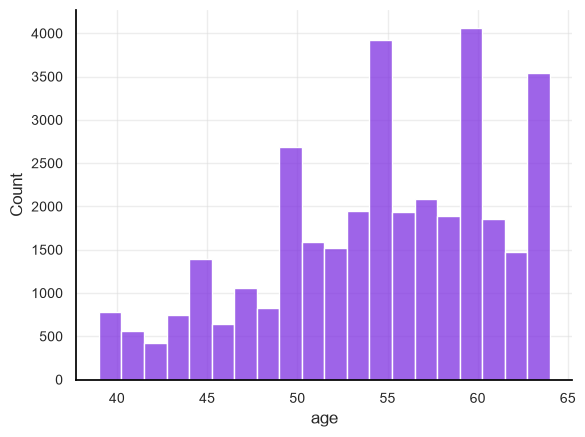

In [160]:
sns.histplot(data=dfYesCardio, x='age',bins=20)

<Axes: xlabel='age', ylabel='Count'>

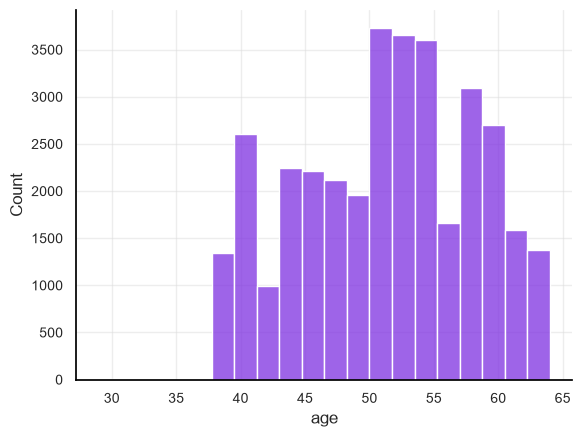

In [161]:
sns.histplot(data=dfNoCardio, x='age',bins=20)

## Pre-Model Training Correlation Research
Correlation analysis is used to measure the relationships between variables. Understanding these relationships helps identify which features may have the greatest influence on cardiovascular disease.

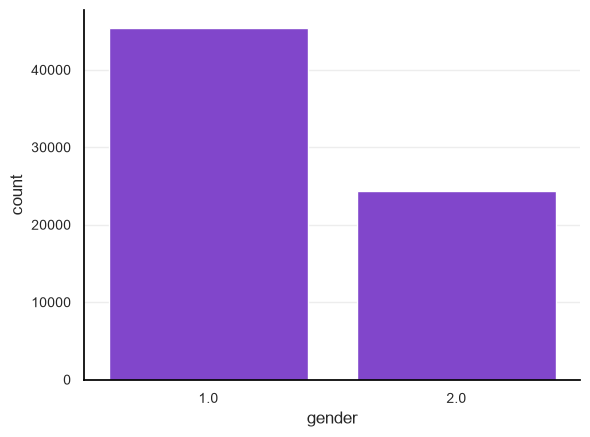

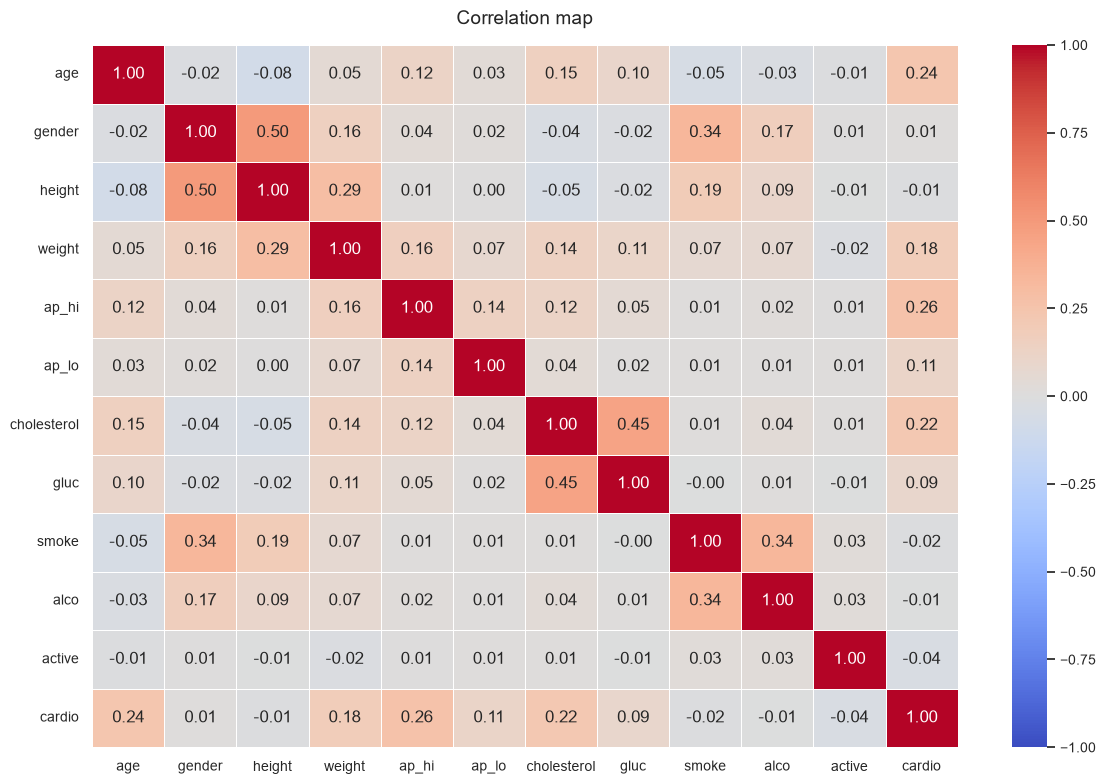

In [162]:
target_corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,)
plt.title(f'Correlation map', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Early Hypothesis Testing
Several hypotheses are investigated before building predictive models. These analyses help determine whether observed relationships in the data support the proposed research questions.

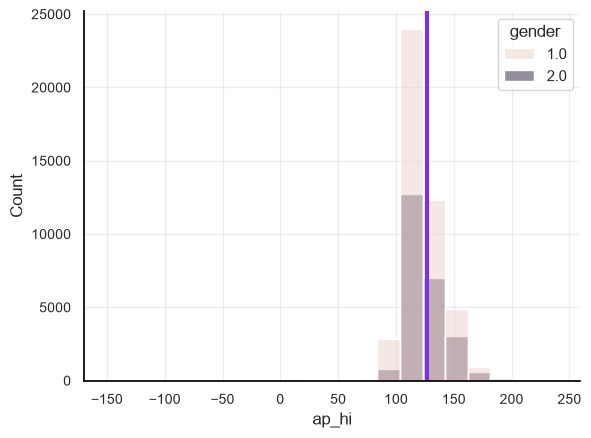

In [165]:
#Men have a lower systolic blood pressure when compared to women
df1 = df[df["ap_hi"] < 250]
sns.histplot(data = df1, x = 'ap_hi',hue = 'gender',bins = 20)
for m in df1.groupby("gender")["ap_hi"].mean():
    plt.axvline(m)

<Axes: xlabel='gender', ylabel='count'>

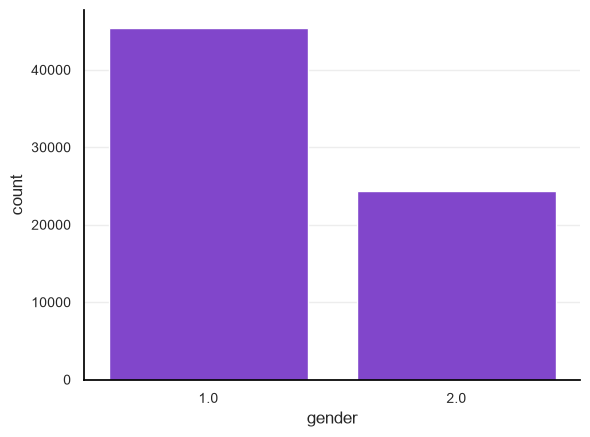

In [166]:
#Data balance check
sns.countplot(data=df,x='gender')


## Model Training,Visualization and Result analysis
Multiple machine learning classification algorithms are trained using the prepared dataset. Their performance is evaluated and compared to determine which model provides the most accurate predictions.

In [168]:
df2 = df[['age','weight','cholesterol','cardio','ap_hi','active']]

In [169]:
display(df2.head())

,age,weight,cholesterol,cardio,ap_hi,active
2,46,63.0,1.0,0,1.0,1
3,49,63.0,1.0,1,140.0,1
4,58,112.0,1.0,1,220.0,1
15,59,129.0,3.0,1,140.0,1
16,55,100.0,1.0,1,160.0,1


In [170]:
df2.dropna(inplace=True)

Your model accuracy is: 70.113%


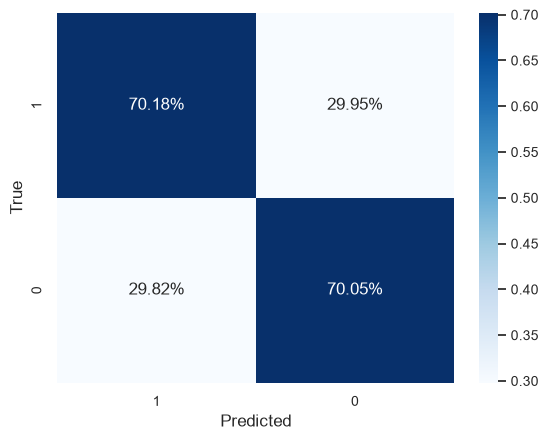

In [171]:
#@title <div dir='rtl' align='right'><font size='3'> על מנת להפעיל את מודל הסיווג, הריצו את התא הבא
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Check data validity
try:
    df2
except NameError:
    df2 = None

if df2 is None:
    print("Please make sure that you created a dataframe with the name: df2 that includes 6 columns")
elif 'cardio' not in df2.columns:
    print('Please make sure that one of the columns of df2 is "cardio"')
elif len(df2.columns) != 6:
    print("Please make sure that you have chosen 6 columns for df2")
elif df2.isnull().values.any():
    print("Machine Learning models don't know how to handle NaN values, please make sure that your table does not have any NaN values")
elif len(df2) < 67_000:
    print("You have removed too many rows from the dataframe, the limit is 3000 rows that can be removed")
else:

    # Prepare features and labels
    all_features = df2.drop('cardio', axis=1)
    true_labels = df2['cardio']

    # Split the data into training and testing sets
    train_test = train_test_split(all_features, true_labels, test_size=0.15, random_state=1)
    features_train, features_test, true_train_labels, true_test_labels = train_test

    # Define and train the KNN model
    knn_model = KNeighborsClassifier(n_neighbors=7)
    knn_model.fit(features_train, true_train_labels)

    # Predict labels for the test set
    pred_labels = knn_model.predict(features_test)

    # Generate and display confusion matrix
    cf_matrix = confusion_matrix(true_test_labels, pred_labels)
    ax = sns.heatmap(cf_matrix/sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set(xlabel='Predicted', ylabel='True')

    # Calculate model accuracy
    accuracy = sum(true_test_labels == pred_labels) / len(true_test_labels) * 100
    print(f"Your model accuracy is: {accuracy:.3f}%")


Your model accuracy is: 70.113%


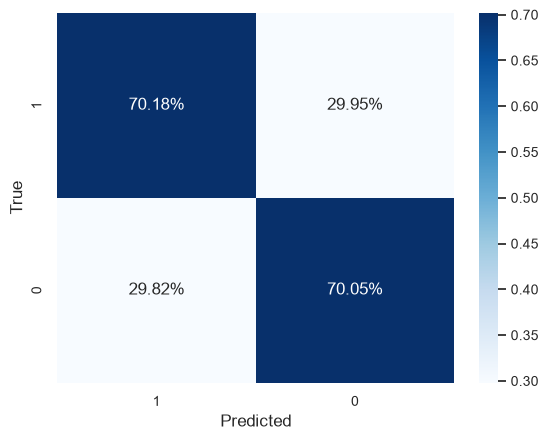

In [172]:
#@title <div dir='rtl'>
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
# Check data validity
try:
    df2
except NameError:
    df2 = None

if df2 is None:
    print("Please make sure that you created a dataframe with the name: df2 that includes 6 columns")
elif 'cardio' not in df2.columns:
    print('Please make sure that one of the columns of df2 is "cardio"')
elif len(df2.columns) != 6:
    print("Please make sure that you have chosen 6 columns for df2")
elif df2.isnull().values.any():
    print("Machine Learning models don't know how to handle NaN values, please make sure that your table does not have any NaN values")
elif len(df2) < 67_000:
    print("You have removed too many rows from the dataframe, the limit is 3000 rows that can be removed")
else:

    # Prepare features and labels
    all_features = df2.drop('cardio', axis=1)
    true_labels = df2['cardio']

    # Split the data into training and testing sets
    train_test = train_test_split(all_features, true_labels, test_size=0.15, random_state=1)
    features_train, features_test, true_train_labels, true_test_labels = train_test

    # Define and train the KNN model
    knn_model = KNeighborsClassifier(n_neighbors=7)
    knn_model.fit(features_train, true_train_labels)

    # Predict labels for the test set
    pred_labels = knn_model.predict(features_test)

    # Generate and display confusion matrix
    cf_matrix = confusion_matrix(true_test_labels, pred_labels)
    ax = sns.heatmap(cf_matrix/sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set(xlabel='Predicted', ylabel='True')

    # Calculate model accuracy
    accuracy = sum(true_test_labels == pred_labels) / len(true_test_labels) * 100
    print(f"Your model accuracy is: {accuracy:.3f}%")


In [173]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_pred = knn_model.predict(features_test)

# Calculate metrics
accuracy = accuracy_score(true_test_labels, y_pred)
precision = precision_score(true_test_labels, y_pred, average='binary')
recall = recall_score(true_test_labels, y_pred, average='binary')
f1 = f1_score(true_test_labels, y_pred, average='binary')

print("========== KNN Results ==========")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

========== KNN Results ==========
Accuracy : 0.701
Precision: 0.702
Recall   : 0.680
F1 Score : 0.691


## Post-Results Hypothesis Researc
After evaluating the models, additional analyses are conducted to further investigate the research questions. This helps determine whether the model results align with the patterns observed during exploratory analysis.

In [174]:
df_cleaned = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 220) & (df['weight'] >= 40) & (df['weight'] <= 180)]

Text(0.5, 1.0, 'How weight affects high blood pressure')

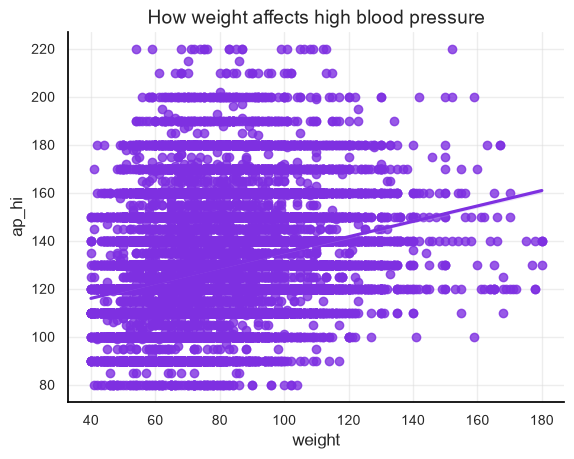

In [175]:
sns.regplot(data=df_cleaned, x='weight', y='ap_hi')
plt.title('How weight affects high blood pressure')

Text(0.5, 1.0, 'blood sugar categories and their weight range')

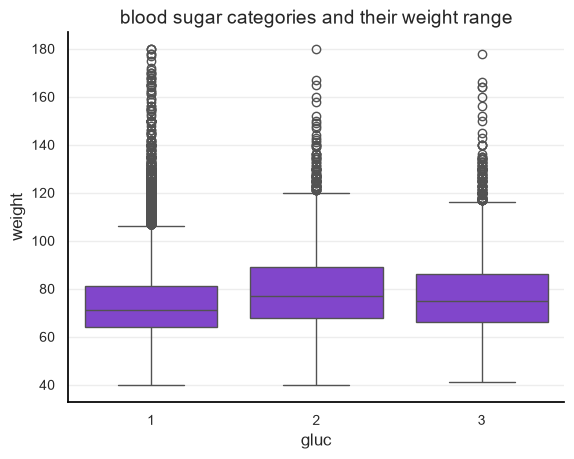

In [176]:
sns.boxplot(data = df_cleaned,x='gluc',y='weight')
plt.title('blood sugar categories and their weight range')

Text(0.5, 1.0, 'Activity analysis within cardio groups')

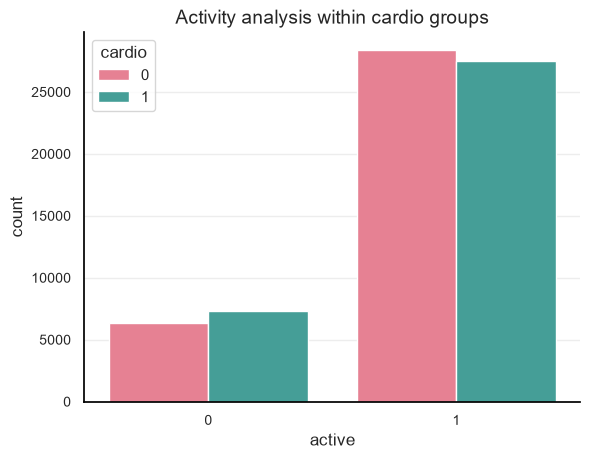

In [177]:
sns.countplot(data = df_cleaned, x='active', hue='cardio')
plt.title('Activity analysis within cardio groups')

Text(0.5, 1.0, 'How weight affects arterial pressure')

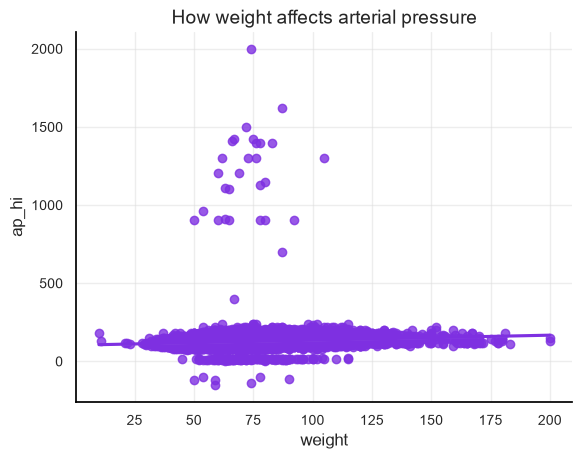

In [178]:
sns.regplot(data=df,x='weight',y="ap_hi")
plt.title("How weight affects arterial pressure")

## Conclusion
The project combines exploratory data analysis with machine learning to investigate cardiovascular disease prediction. The results highlight meaningful relationships between several health indicators and demonstrate the effectiveness of classification techniques for this problem.